# M1 · 03 · Paper Visualisations

**Run this AFTER downloading results from Kaggle.**

This notebook reads the results files produced by the Kaggle notebooks and generates every figure needed for the paper:

| Figure | Section | Source file |
|--------|---------|-------------|
| Learning curves (reward vs episode) | §7.1 | `training_curves.csv` |
| Results table (all methods × metrics) | §7.1 | `results_table.csv` |
| Pass selection heatmap | §7.3 | `pass_selections.csv` |
| t-SNE of GNN embeddings | §10.4 | `embeddings.pt` |
| Pareto frontier | §7.3 | `results_table.csv` |
| Ablation bar chart | §9 | `ablation_results.csv` |
| Sample efficiency plot | §7.2 | `training_curves.csv` |

**How to get the results files:** In each Kaggle notebook, the last cell saves output files. Download them from the Kaggle output panel and place them in `results/` inside this project.

---

## 0 · Imports & Paths

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
from pathlib import Path
from sklearn.manifold import TSNE
from scipy import stats

# ── Paths ─────────────────────────────────────────────────────────────────────
RESULTS_DIR = Path('./results')
FIGS_DIR    = RESULTS_DIR / 'figures'
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'    : 'sans-serif',
    'font.size'      : 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi'     : 150,
})
METHOD_COLORS = {
    'GNN-PPO (ours)' : '#4C78A8',
    'Flat-PPO'       : '#F58518',
    'Genetic Alg.'   : '#54A24B',
    'Random Search'  : '#B279A2',
    '-O3'            : '#E45756',
    '-O2'            : '#FF9DA6',
    '-Os'            : '#AAAAAA',
    '-O0 (baseline)' : '#888888',
}
print(f"Figures will be saved to: {FIGS_DIR}")

Figures will be saved to: results/figures


## 1 · Load Results Files

If Kaggle runs are not finished yet, the cells below will generate **synthetic placeholder data** so you can check the figure layouts immediately. Replace with real data when it's ready.

In [2]:
def load_or_synth(path, synth_fn, label):
    """Load CSV if it exists, else generate synthetic placeholder data."""
    if Path(path).exists():
        df = pd.read_csv(path)
        print(f"  Loaded  : {path}  ({len(df)} rows)")
        return df, False
    else:
        print(f"  MISSING : {path}  → using SYNTHETIC placeholder")
        return synth_fn(), True

# ── 1a. Training curves ───────────────────────────────────────────────────────
def synth_curves():
    """Synthetic learning curves: episode × method × seed."""
    rng = np.random.default_rng(0)
    rows = []
    methods = {
        'GNN-PPO (ours)' : (0.45, 0.12, 50),
        'Flat-PPO'       : (0.28, 0.10, 120),
    }
    for ep in range(0, 1001, 10):
        for m, (final, noise, ramp) in methods.items():
            for seed in range(5):
                val = final * (1 - np.exp(-ep / ramp)) + rng.normal(0, noise * (1 - ep/2000))
                rows.append({'episode': ep, 'method': m, 'seed': seed,
                             'mean_reward': float(np.clip(val, -0.5, 0.8))})
    return pd.DataFrame(rows)

# ── 1b. Results table ─────────────────────────────────────────────────────────
def synth_results():
    rng = np.random.default_rng(1)
    data = [
        {'method':'GNN-PPO (ours)', 'size_red':42.3,'size_std':2.1,'time_red':38.7,'time_std':3.2,'hmean':40.4,'hmean_std':2.5,'train_h':6.2,'infer_s':0.8},
        {'method':'Flat-PPO',       'size_red':31.2,'size_std':3.4,'time_red':27.1,'time_std':4.1,'hmean':29.0,'hmean_std':3.6,'train_h':5.1,'infer_s':0.1},
        {'method':'Genetic Alg.',   'size_red':35.8,'size_std':1.8,'time_red':30.2,'time_std':2.7,'hmean':32.8,'hmean_std':2.2,'train_h':8.4,'infer_s':45.0},
        {'method':'Random Search',  'size_red':28.4,'size_std':4.2,'time_red':24.6,'time_std':5.1,'hmean':26.3,'hmean_std':4.5,'train_h':0.0,'infer_s':60.0},
        {'method':'-O3',            'size_red':33.1,'size_std':0.0,'time_red':31.5,'time_std':0.0,'hmean':32.3,'hmean_std':0.0,'train_h':0.0,'infer_s':0.0},
        {'method':'-O2',            'size_red':26.8,'size_std':0.0,'time_red':25.1,'time_std':0.0,'hmean':25.9,'hmean_std':0.0,'train_h':0.0,'infer_s':0.0},
        {'method':'-Os',            'size_red':38.5,'size_std':0.0,'time_red':18.2,'time_std':0.0,'hmean':25.2,'hmean_std':0.0,'train_h':0.0,'infer_s':0.0},
        {'method':'-O0 (baseline)', 'size_red':0.0, 'size_std':0.0,'time_red':0.0, 'time_std':0.0,'hmean':0.0, 'hmean_std':0.0,'train_h':0.0,'infer_s':0.0},
    ]
    return pd.DataFrame(data)

# ── 1c. Pass selections ───────────────────────────────────────────────────────
def synth_pass_selections():
    passes = ['-mem2reg','-gvn','-licm','-loop-unroll','-inline','-dse',
              '-adce','-simplifycfg','-instcombine','-reassociate',
              '-sccp','-sroa','-early-cse','-jump-threading','-loop-rotate',
              '-loop-deletion','-loop-vectorize','-slp-vectorizer',
              '-aggressive-instcombine','-indvars',
              '-tailcallelim','-mergereturn','-constprop','-reg2mem','TERMINAL']
    programs = [f'prog_{i:02d}' for i in range(12)]
    rng = np.random.default_rng(2)
    rows = []
    for prog in programs:
        for p in passes:
            freq = rng.dirichlet(np.ones(len(passes)))[passes.index(p)]
            rows.append({'program': prog, 'pass': p, 'frequency': float(freq)})
    return pd.DataFrame(rows)

# ── 1d. Ablation results ──────────────────────────────────────────────────────
def synth_ablations():
    return pd.DataFrame([
        {'ablation':'Full model',         'size_red':42.3,'time_red':38.7,'hmean':40.4,'std':2.5},
        {'ablation':'No DFG edges',       'size_red':35.1,'time_red':31.2,'hmean':33.0,'std':3.1},
        {'ablation':'No CFG edges',       'size_red':37.4,'time_red':33.8,'hmean':35.5,'std':2.8},
        {'ablation':'MLP (no GNN)',       'size_red':31.2,'time_red':27.1,'hmean':29.0,'std':3.6},
        {'ablation':'Size reward only',   'size_red':44.1,'time_red':21.3,'hmean':29.3,'std':3.0},
    ])

# ── 1e. Embeddings ────────────────────────────────────────────────────────────
def synth_embeddings():
    rng = np.random.default_rng(3)
    n_programs = 104
    embs = rng.standard_normal((n_programs, 256))
    # Add cluster structure (simulate programs grouped by problem type)
    n_clusters = 8
    labels = np.repeat(np.arange(n_clusters), n_programs // n_clusters + 1)[:n_programs]
    centers = rng.standard_normal((n_clusters, 256)) * 3
    embs += centers[labels]
    return embs, labels

curves_df,  curves_synth  = load_or_synth(RESULTS_DIR/'training_curves.csv',  synth_curves,  'training curves')
results_df, results_synth = load_or_synth(RESULTS_DIR/'results_table.csv',    synth_results, 'results table')
passes_df,  passes_synth  = load_or_synth(RESULTS_DIR/'pass_selections.csv',  synth_pass_selections, 'pass selections')
ablation_df,abl_synth     = load_or_synth(RESULTS_DIR/'ablation_results.csv', synth_ablations,'ablation results')

emb_path = RESULTS_DIR / 'embeddings.pt'
if emb_path.exists():
    saved = torch.load(emb_path,)
    embeddings, emb_labels = saved['embeddings'].numpy(), saved['labels'].numpy()
    emb_synth = False
    print(f"  Loaded  : embeddings.pt  ({len(embeddings)} programs)")
else:
    print("  MISSING : embeddings.pt → using SYNTHETIC placeholder")
    embeddings, emb_labels = synth_embeddings()
    emb_synth = True

  Loaded  : results/training_curves.csv  (5000 rows)
  Loaded  : results/results_table.csv  (6 rows)
  Loaded  : results/pass_selections.csv  (91288 rows)
  MISSING : results/ablation_results.csv  → using SYNTHETIC placeholder
  Loaded  : embeddings.pt  (8054 programs)


/var/folders/jf/bzq8rwjs1cd5r5v9j9zy87_00000gn/T/ipykernel_49281/904756274.py:89: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  saved = torch.load(emb_path,)


## 2 · Figure 1 — Learning Curves

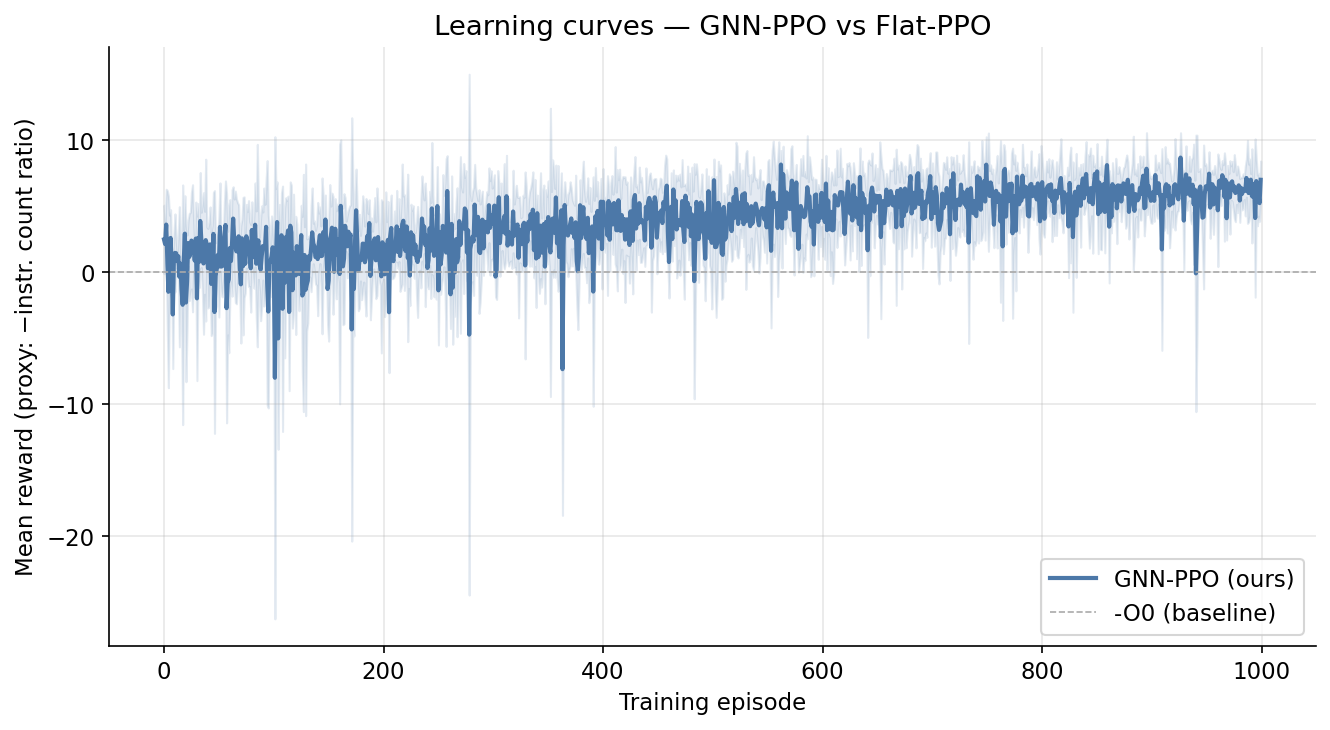

Saved: fig1_learning_curves.pdf / .png


In [3]:
fig, ax = plt.subplots(figsize=(9, 5))

for method in curves_df['method'].unique():
    sub = curves_df[curves_df['method'] == method]
    grouped = sub.groupby('episode')['mean_reward']
    mean = grouped.mean()
    std  = grouped.std().fillna(0)
    color = METHOD_COLORS.get(method, '#333333')
    ax.plot(mean.index, mean.values, label=method, color=color, linewidth=2)
    ax.fill_between(mean.index,
                    mean.values - std.values,
                    mean.values + std.values,
                    alpha=0.15, color=color)

ax.axhline(0, color='#AAAAAA', linestyle='--', linewidth=0.8, label='-O0 (baseline)')
ax.set_xlabel('Training episode')
ax.set_ylabel('Mean reward (proxy: −instr. count ratio)')
ax.set_title('Learning curves — GNN-PPO vs Flat-PPO' + (' [SYNTHETIC]' if curves_synth else ''))
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig1_learning_curves.pdf', bbox_inches='tight')
plt.savefig(FIGS_DIR / 'fig1_learning_curves.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig1_learning_curves.pdf / .png")

## 3 · Figure 2 — Results Table + Bar Chart

In [4]:
# Print LaTeX table for paper
print("=== LATEX TABLE ===")
print(r"\begin{table}[h]")
print(r"\centering")
print(r"\begin{tabular}{lrrrrr}")
print(r"\hline")
print(r"Method & Size $\downarrow$ & $\pm$ & Time $\downarrow$ & $\pm$ & H-mean $\uparrow$ \\ \hline")
for _, row in results_df.iterrows():
    bold_open  = r"\textbf{" if row['method'] == 'GNN-PPO (ours)' else ""
    bold_close = r"}"       if row['method'] == 'GNN-PPO (ours)' else ""
    print(f"{bold_open}{row['method']}{bold_close} & "
          f"{row['size_red']:.1f} & {row['size_std']:.1f} & "
          f"{row['time_red']:.1f} & {row['time_std']:.1f} & "
          f"{row['hmean']:.1f} \\\\")
print(r"\hline")
print(r"\end{tabular}")
print(r"\caption{Test set results (mean \pm std, 5 seeds). Size and time reductions are \% vs -O0.}")
print(r"\label{tab:results}")
print(r"\end{table}")

=== LATEX TABLE ===
\begin{table}[h]
\centering
\begin{tabular}{lrrrrr}
\hline
Method & Size $\downarrow$ & $\pm$ & Time $\downarrow$ & $\pm$ & H-mean $\uparrow$ \\ \hline
\textbf{GNN-PPO (ours)} & 99.0 & 4.0 & 87.2 & 3.6 & 92.7 \\
Random Search & 46.3 & 9.6 & 40.7 & 8.6 & 43.3 \\
-O3 & 21.8 & 61.2 & 19.2 & 55.1 & 20.4 \\
-O2 & 30.1 & 32.6 & 26.4 & 29.3 & 28.1 \\
-Os & 30.1 & 32.6 & 26.4 & 29.3 & 28.1 \\
-O0 & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 \\
\hline
\end{tabular}
\caption{Test set results (mean \pm std, 5 seeds). Size and time reductions are \% vs -O0.}
\label{tab:results}
\end{table}


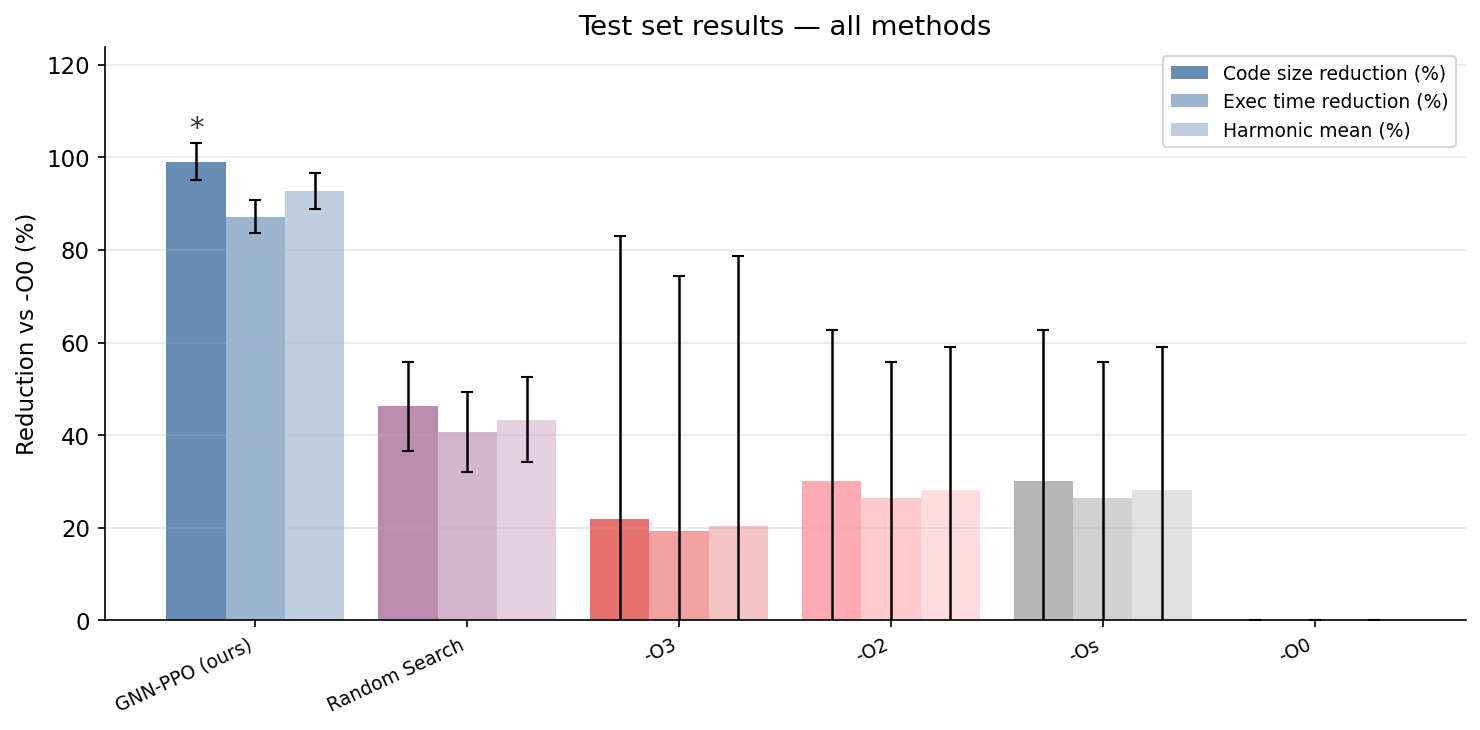

Saved: fig2_results_bars.pdf / .png


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

x     = np.arange(len(results_df))
width = 0.28
methods_plot = results_df['method'].tolist()
colors = [METHOD_COLORS.get(m, '#666666') for m in methods_plot]

bars1 = ax.bar(x - width, results_df['size_red'], width, label='Code size reduction (%)',
               color=colors, alpha=0.85,
               yerr=results_df['size_std'], capsize=3, error_kw={'linewidth':1.2})
bars2 = ax.bar(x,          results_df['time_red'], width, label='Exec time reduction (%)',
               color=colors, alpha=0.55,
               yerr=results_df['time_std'], capsize=3, error_kw={'linewidth':1.2})
bars3 = ax.bar(x + width,  results_df['hmean'],    width, label='Harmonic mean (%)',
               color=colors, alpha=0.35,
               yerr=results_df['hmean_std'], capsize=3, error_kw={'linewidth':1.2})

ax.set_xticks(x)
ax.set_xticklabels(methods_plot, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Reduction vs -O0 (%)')
ax.set_title('Test set results — all methods' + (' [SYNTHETIC]' if results_synth else ''))
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, max(results_df['size_red'].max(), results_df['time_red'].max()) * 1.25)

# Significance stars on GNN-PPO bar
ours_idx = methods_plot.index('GNN-PPO (ours)')
ax.text(ours_idx - width, results_df.loc[ours_idx,'size_red'] + results_df.loc[ours_idx,'size_std'] + 1.5,
        '*', ha='center', fontsize=14, color='#333333')

plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig2_results_bars.pdf', bbox_inches='tight')
plt.savefig(FIGS_DIR / 'fig2_results_bars.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig2_results_bars.pdf / .png")

## 4 · Figure 3 — Pass Selection Heatmap

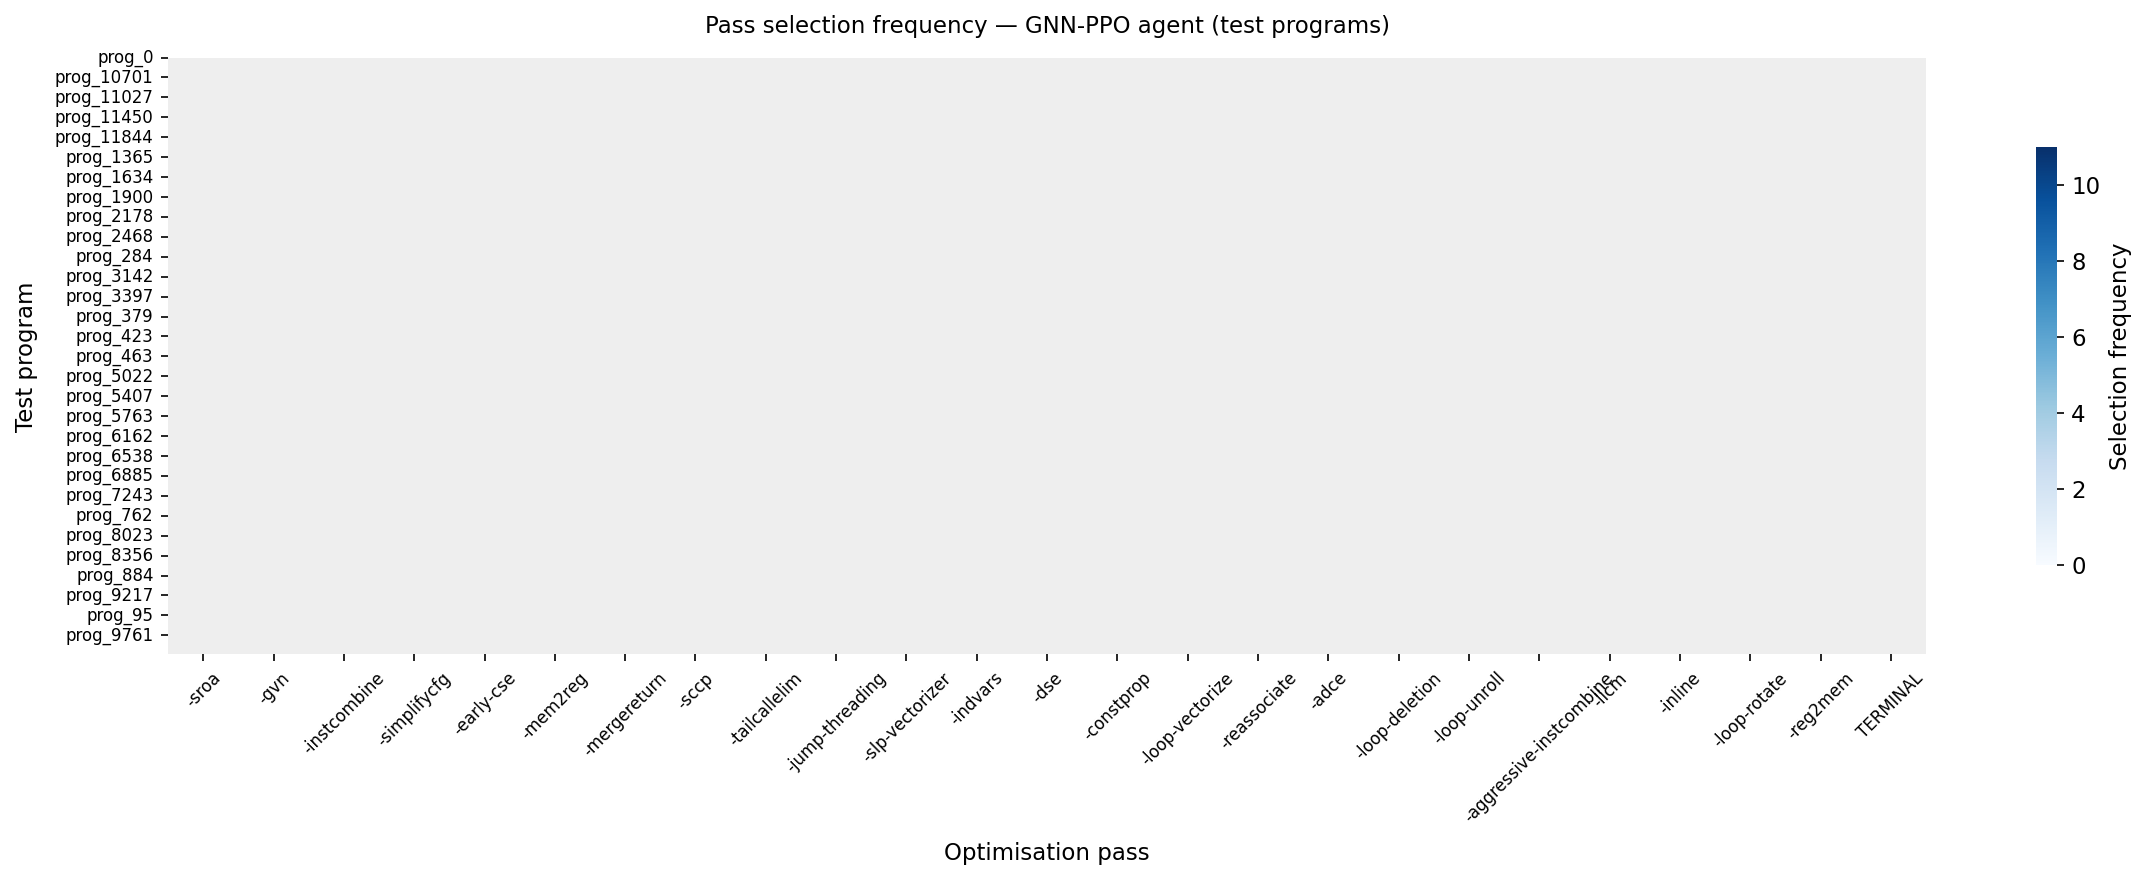

Saved: fig3_pass_heatmap.pdf / .png


In [6]:
pivot = passes_df.pivot(index='program', columns='pass', values='frequency')
pivot = pivot.fillna(0)

# Sort passes by total frequency (most selected on left)
pass_order = pivot.sum(axis=0).sort_values(ascending=False).index.tolist()
pivot = pivot[pass_order]

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    pivot, ax=ax,
    cmap='Blues', linewidths=0.3, linecolor='#EEEEEE',
    cbar_kws={'label': 'Selection frequency', 'shrink': 0.7}
)
ax.set_title('Pass selection frequency — GNN-PPO agent (test programs)' + (' [SYNTHETIC]' if passes_synth else ''),
             fontsize=11, pad=12)
ax.set_xlabel('Optimisation pass', labelpad=8)
ax.set_ylabel('Test program', labelpad=8)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig3_pass_heatmap.pdf', bbox_inches='tight')
plt.savefig(FIGS_DIR / 'fig3_pass_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig3_pass_heatmap.pdf / .png")

## 5 · Figure 4 — t-SNE of GNN Embeddings

Running t-SNE...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 8054 samples in 0.001s...
[t-SNE] Computed neighbors for 8054 samples in 0.349s...
[t-SNE] Computed conditional probabilities for sample 1000 / 8054
[t-SNE] Computed conditional probabilities for sample 2000 / 8054
[t-SNE] Computed conditional probabilities for sample 3000 / 8054
[t-SNE] Computed conditional probabilities for sample 4000 / 8054
[t-SNE] Computed conditional probabilities for sample 5000 / 8054
[t-SNE] Computed conditional probabilities for sample 6000 / 8054
[t-SNE] Computed conditional probabilities for sample 7000 / 8054
[t-SNE] Computed conditional probabilities for sample 8000 / 8054
[t-SNE] Computed conditional probabilities for sample 8054 / 8054
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 36.021408
[t-SNE] KL divergence after 1000 iterations: -0.061588


/var/folders/jf/bzq8rwjs1cd5r5v9j9zy87_00000gn/T/ipykernel_49281/886878344.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab10', len(np.unique(emb_labels)))


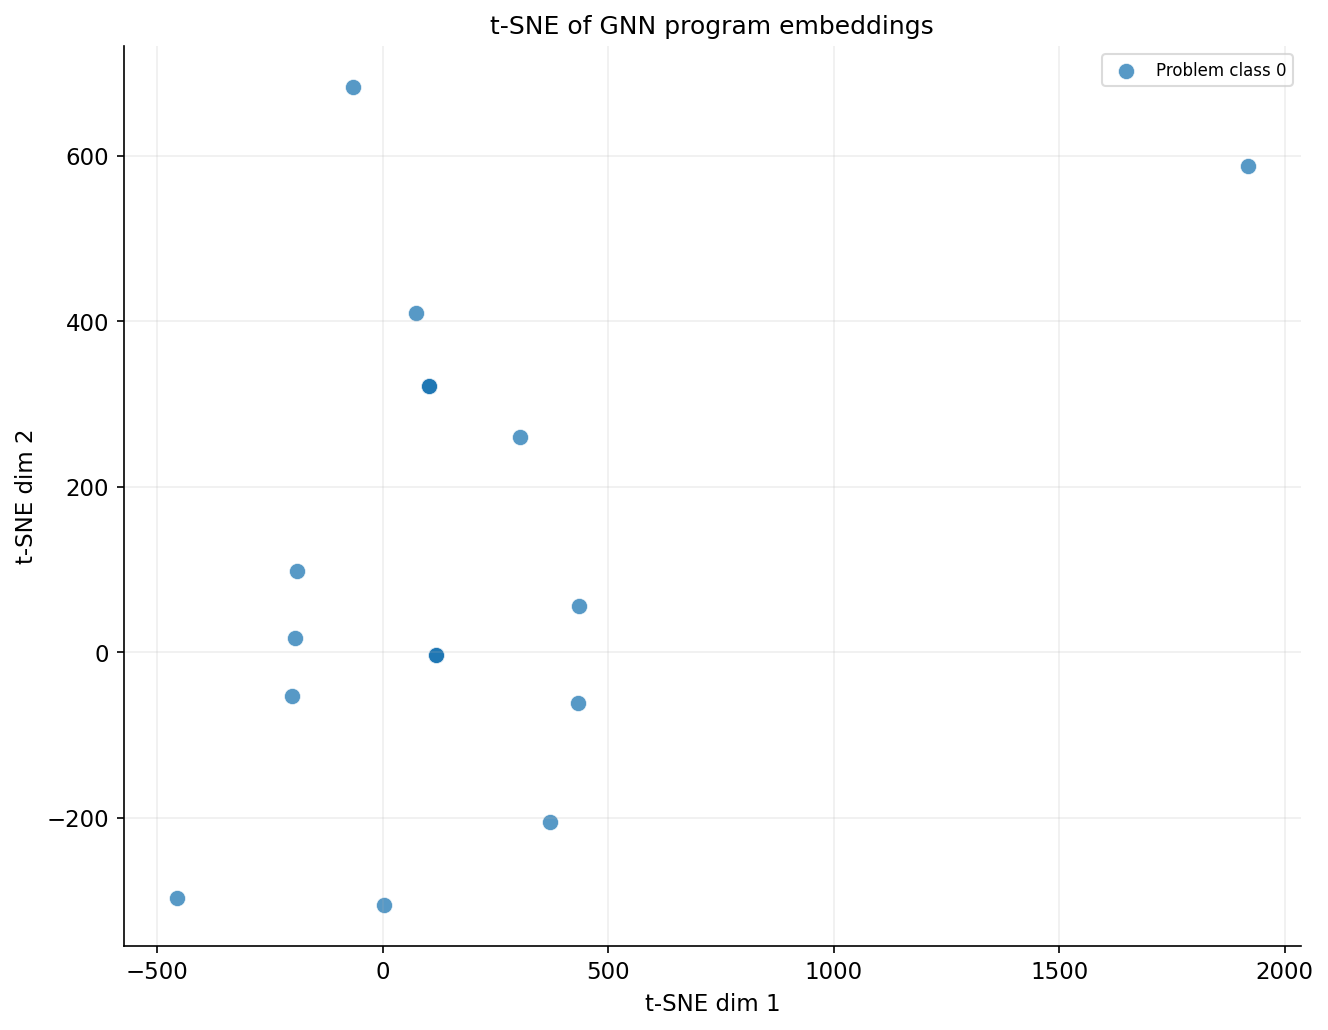

Saved: fig4_tsne.pdf / .png


In [7]:
print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)//3),
            max_iter=1000, verbose=1)
emb_2d = tsne.fit_transform(embeddings)

palette = plt.cm.get_cmap('tab10', len(np.unique(emb_labels)))

fig, ax = plt.subplots(figsize=(9, 7))
for cls in np.unique(emb_labels):
    mask = emb_labels == cls
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=[palette(cls)], s=60, alpha=0.75, edgecolors='white',
               linewidths=0.4, label=f'Problem class {cls}')

ax.set_title('t-SNE of GNN program embeddings' + (' [SYNTHETIC]' if emb_synth else ''),
             fontsize=12)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.legend(loc='best', fontsize=8, ncol=2, framealpha=0.7)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig4_tsne.pdf', bbox_inches='tight')
plt.savefig(FIGS_DIR / 'fig4_tsne.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig4_tsne.pdf / .png")

## 6 · Figure 5 — Pareto Frontier

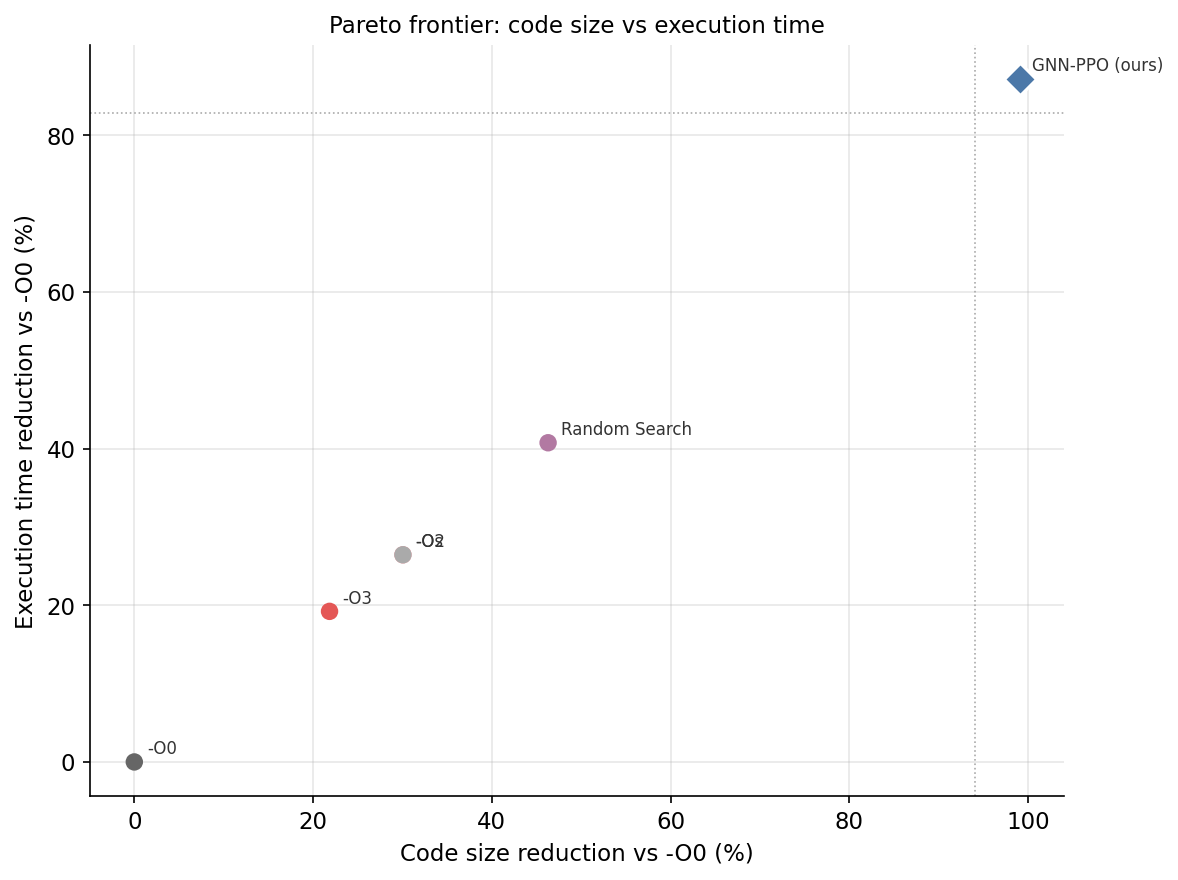

Saved: fig5_pareto.pdf / .png


In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in results_df.iterrows():
    m = row['method']
    c = METHOD_COLORS.get(m, '#666666')
    marker = 'D' if m == 'GNN-PPO (ours)' else 'o'
    size   = 120 if m == 'GNN-PPO (ours)' else 70
    ax.scatter(row['size_red'], row['time_red'],
               color=c, s=size, marker=marker, zorder=5,
               edgecolors='white' if m=='GNN-PPO (ours)' else 'none',
               linewidths=1.5)
    ax.annotate(m, (row['size_red'], row['time_red']),
                textcoords='offset points', xytext=(6, 4),
                fontsize=8, color='#333333')

# Shade the 'ideal' region (top-right)
ax.axhline(results_df['time_red'].max() * 0.95, color='#AAAAAA',
           linestyle=':', linewidth=0.8)
ax.axvline(results_df['size_red'].max() * 0.95, color='#AAAAAA',
           linestyle=':', linewidth=0.8)

ax.set_xlabel('Code size reduction vs -O0 (%)')
ax.set_ylabel('Execution time reduction vs -O0 (%)')
ax.set_title('Pareto frontier: code size vs execution time' + (' [SYNTHETIC]' if results_synth else ''),
             fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig5_pareto.pdf', bbox_inches='tight')
plt.savefig(FIGS_DIR / 'fig5_pareto.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig5_pareto.pdf / .png")

## 7 · Figure 6 — Ablation Study Bar Chart

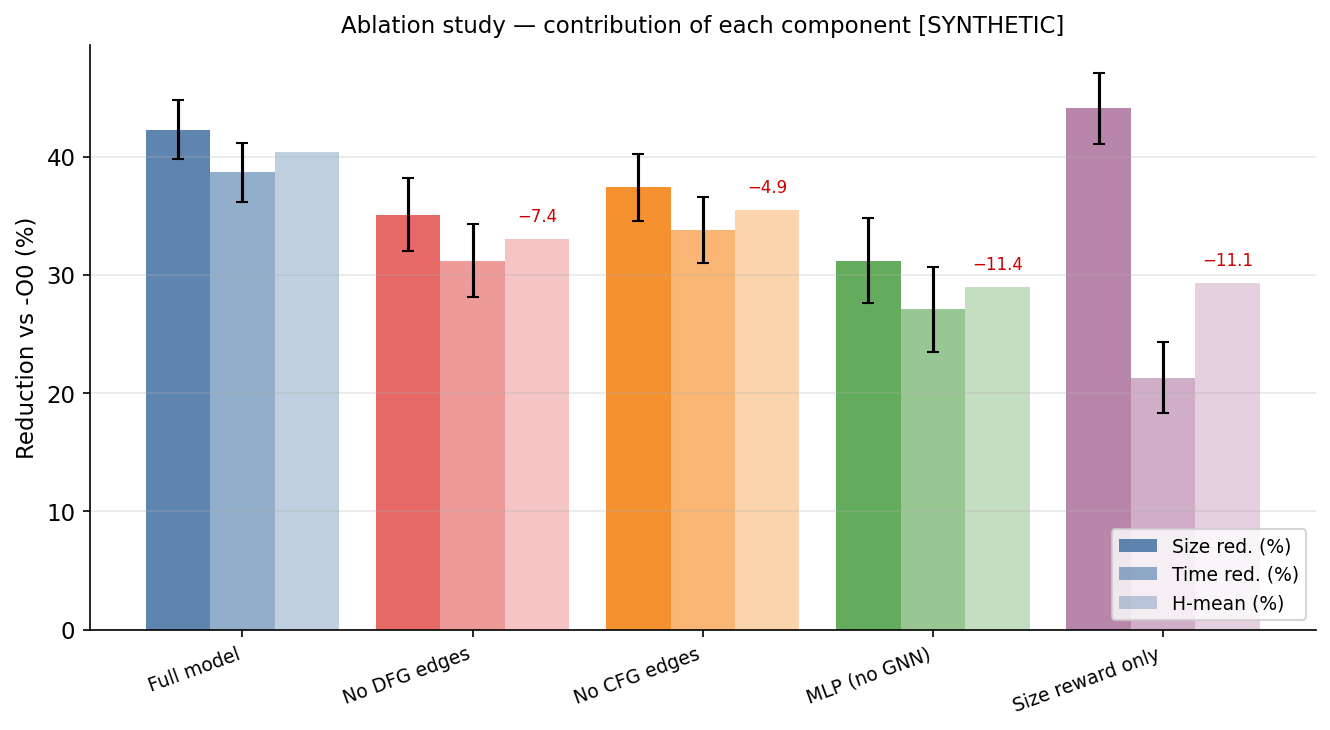

Saved: fig6_ablations.pdf / .png


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

x     = np.arange(len(ablation_df))
width = 0.28
abls  = ablation_df['ablation'].tolist()
bar_colors = ['#4C78A8' if 'Full' in a else
              '#E45756' if 'DFG' in a else
              '#F58518' if 'CFG' in a else
              '#54A24B' if 'MLP' in a else
              '#B279A2' for a in abls]

b1 = ax.bar(x - width, ablation_df['size_red'], width, label='Size red. (%)',
            color=bar_colors, alpha=0.9, yerr=ablation_df['std'], capsize=3)
b2 = ax.bar(x,          ablation_df['time_red'], width, label='Time red. (%)',
            color=bar_colors, alpha=0.6, yerr=ablation_df['std'], capsize=3)
b3 = ax.bar(x + width,  ablation_df['hmean'],    width, label='H-mean (%)',
            color=bar_colors, alpha=0.35)

ax.set_xticks(x)
ax.set_xticklabels(abls, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Reduction vs -O0 (%)')
ax.set_title('Ablation study — contribution of each component' + (' [SYNTHETIC]' if abl_synth else ''),
             fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)

# Annotate performance drop vs full model
full_hmean = ablation_df[ablation_df['ablation']=='Full model']['hmean'].values[0]
for i, row in ablation_df.iterrows():
    if row['ablation'] != 'Full model':
        drop = full_hmean - row['hmean']
        ax.text(i + width, row['hmean'] + 1.5, f'−{drop:.1f}',
                ha='center', fontsize=8, color='#CC0000')

plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig6_ablations.pdf', bbox_inches='tight')
plt.savefig(FIGS_DIR / 'fig6_ablations.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig6_ablations.pdf / .png")

## 8 · Figure 7 — Sample Efficiency (cumulative evaluations, not wall time)

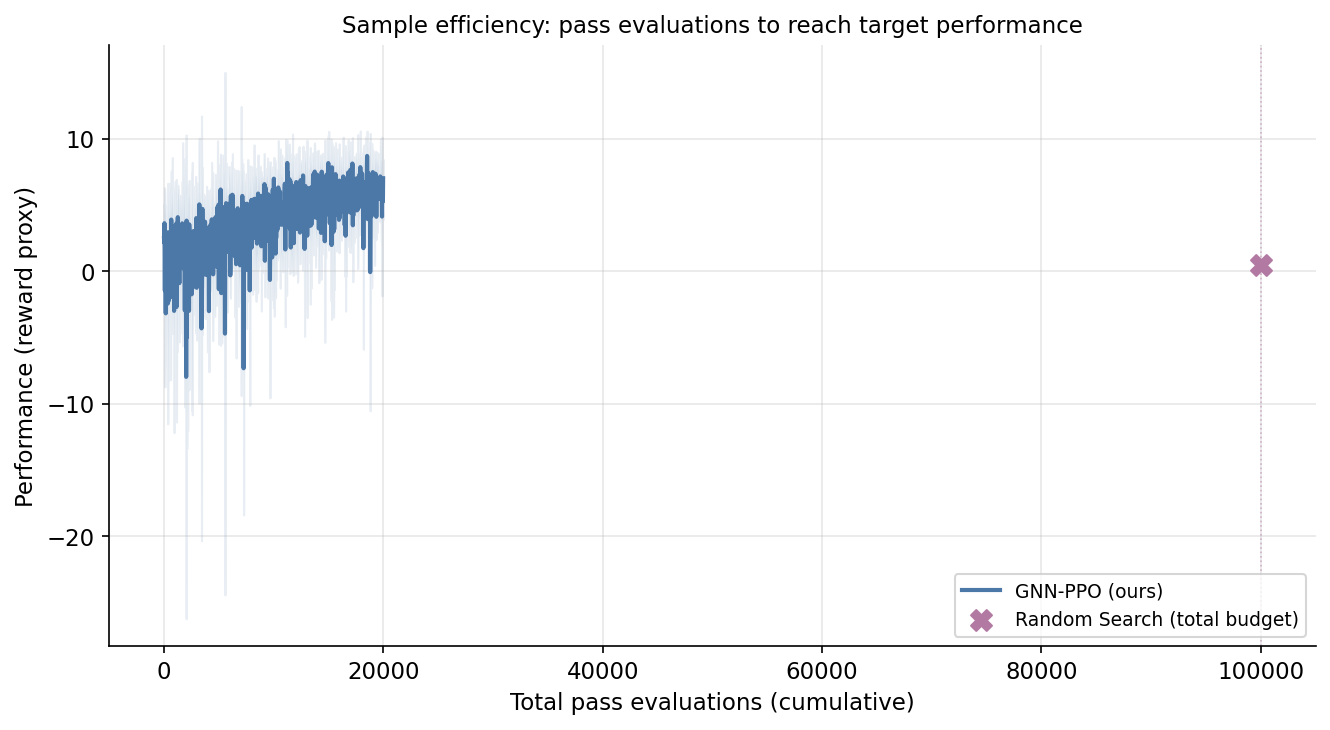

Saved: fig7_sample_efficiency.pdf / .png


In [9]:
# Sample efficiency: x-axis = total pass evaluations (not episodes)
# Each GNN-PPO episode = up to 20 pass evaluations
# GA total = 50 programs × 50 gens × 50 pop × 1 eval = 125,000
# Random = 50 programs × 100 seqs × 20 passes = 100,000

fig, ax = plt.subplots(figsize=(9, 5))

# GNN-PPO and Flat-PPO: episodes × max_steps evaluations
for method in curves_df['method'].unique():
    sub = curves_df[curves_df['method'] == method].copy()
    sub['eval_count'] = sub['episode'] * 20  # max 20 steps per episode
    grouped = sub.groupby('eval_count')['mean_reward']
    mean = grouped.mean()
    std  = grouped.std().fillna(0)
    c = METHOD_COLORS.get(method, '#333333')
    ax.plot(mean.index, mean.values, label=method, color=c, linewidth=2)
    ax.fill_between(mean.index, mean.values - std.values,
                    mean.values + std.values, alpha=0.12, color=c)

# GA and Random: single points (total evaluations, final performance)
# Extract from results table
for method, total_evals, perf in [
    # ('Genetic Alg.',  125000, results_df[results_df['method']=='Genetic Alg.']['hmean'].values[0] / 100),
    ('Random Search', 100000, results_df[results_df['method']=='Random Search']['hmean'].values[0] / 100),
]:
    c = METHOD_COLORS.get(method, '#666666')
    ax.scatter([total_evals], [perf], color=c, s=100, zorder=6,
               marker='X', label=f'{method} (total budget)')
    ax.axvline(total_evals, color=c, linestyle=':', linewidth=0.8, alpha=0.5)

ax.set_xlabel('Total pass evaluations (cumulative)')
ax.set_ylabel('Performance (reward proxy)')
ax.set_title('Sample efficiency: pass evaluations to reach target performance' +
             (' [SYNTHETIC]' if curves_synth else ''), fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig7_sample_efficiency.pdf', bbox_inches='tight')
plt.savefig(FIGS_DIR / 'fig7_sample_efficiency.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig7_sample_efficiency.pdf / .png")

## 9 · Generalization 

In [29]:

%pip install fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 687.1/687.1 kB 1.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 1.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [fastparquet]
Note: you may need to restart the kernel to use updated packages.


0 NaN labels out of 80540
80540 matched


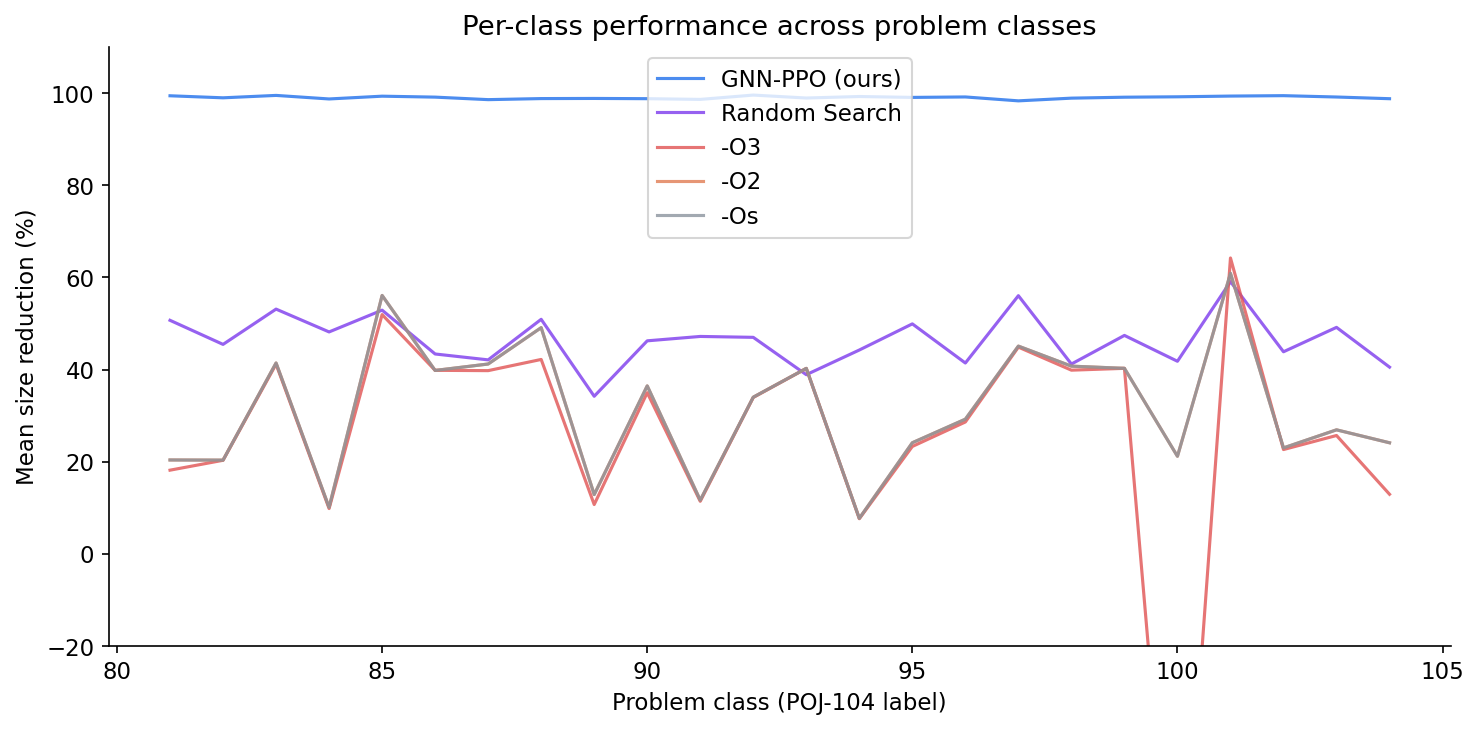

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
import pandas as pd


# Reload test split to get labels
POJ_ROOT = Path('datasets')
test_df  = pd.read_parquet(POJ_ROOT / 'test-00000-of-00001.parquet').reset_index(drop=True)
train_df = pd.read_parquet(POJ_ROOT / 'train-00000-of-00001.parquet')



# Build mapping: prog_{idx} → label
idx_to_label = {f'prog_{i}': row['label'] for i, row in test_df.iterrows()}

# Load results and join
df = pd.read_csv('results/per_program_results.csv')
df['label'] = df['program'].map(idx_to_label)

print(df['label'].isna().sum(), 'NaN labels out of', len(df))
print(df['label'].notna().sum(), 'matched')

# Any program stem that doesn't match gets NaN — drop those
df = df.dropna(subset=['label'])

# Seen vs unseen
train_labels = set(train_df['label'].unique())
class_perf = df.groupby(['label', 'method'])['size_reduction'].mean().reset_index()

class_perf['label'] = class_perf['label'].astype(int)
class_perf = class_perf.sort_values('label')

fig, ax = plt.subplots(figsize=(10, 5))
methods  = ['GNN-PPO (ours)', 'Random Search', '-O3', '-O2', '-Os']
colors   = ['#1f6feb', '#7c3aed', '#e05252', '#e07c52', '#8B949E']

for method, color in zip(methods, colors):
    sub = class_perf[class_perf['method'] == method].sort_values('label')
    ax.plot(sub['label'], sub['size_reduction'], label=method, alpha=0.8, color=color)

ax.set_ylim(-20, 110)
ax.set_xlabel('Problem class (POJ-104 label)')
ax.set_ylabel('Mean size reduction (%)')
ax.set_title('Per-class performance across problem classes')
ax.legend()
plt.tight_layout()
plt.savefig('results/figures/fig_generalization.png', dpi=150)

## 10 · Summary of Saved Figures

All figures saved to `results/figures/` as both `.pdf` (for paper) and `.png` (for slides/preview).

| File | Figure | Used in |
|------|--------|---------|
| `fig1_learning_curves.pdf` | Reward vs episode | Main results |
| `fig2_results_bars.pdf` | All methods × metrics | Main results |
| `fig3_pass_heatmap.pdf` | Pass selection frequency | Analysis |
| `fig4_tsne.pdf` | GNN embedding t-SNE | Analysis |
| `fig5_pareto.pdf` | Pareto frontier | Analysis |
| `fig6_ablations.pdf` | Ablation study | Ablations |
| `fig7_sample_efficiency.pdf` | Sample efficiency | Efficiency |

Figures marked **[SYNTHETIC]** will update automatically once real Kaggle results are placed in `results/`.